# Exploración y Análisis de Datos con yfinance (OHLCV)  
Este notebook descarga datos desde **Yahoo Finance** usando `yfinance` y realiza un análisis exploratorio completo con **tablas y gráficas**.

**Qué incluye**
- Descarga de datos (acciones/ETFs/índices) y guardado en CSV (opcional)
- Revisión de estructura, tipos, valores nulos, duplicados
- Estadísticos descriptivos
- Rendimientos (simple y log), volatilidad rolling
- Drawdowns y métricas básicas de riesgo
- Comparación multi-activo y correlaciones
- Análisis de volumen
- Detección visual de cambios de régimen (rolling stats)

> Recomendación TFM: usa este notebook como “base de exploración” y luego migra funciones a `src/`.


## 0) Setup

In [6]:
# Si ejecutas en Colab, descomenta:
# !uv pip install -r requirements.txt

from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import time

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Carpetas (ajusta si tu repo tiene otra estructura)
# DATA_RAW = Path("../data/raw")
# DATA_RAW.mkdir(parents=True, exist_ok=True)

print("OK - Librerías cargadas")

OK - Librerías cargadas


## 1) Configuración: tickers y rango temporal

In [7]:
# Tickers típicos
# SPY = S&P500 ETF, QQQ = Nasdaq100 ETF, ^VIX = volatilidad, ^GSPC = índice S&P500
TICKERS = ["SPY", "QQQ", "^GSPC", "^VIX"]
START = "2000-01-01"
END = None  # None = hasta hoy

INTERVAL = "1d"  # '1d', '1wk', '1mo' (intradía depende de limitaciones de Yahoo)

print("Tickers:", TICKERS)
print("Start:", START, "End:", END, "Interval:", INTERVAL)

Tickers: ['SPY', 'QQQ', '^GSPC', '^VIX']
Start: 2000-01-01 End: None Interval: 1d


## 2) Descarga de datos (OHLCV)

In [8]:
# Descarga multi-ticker.
# group_by='ticker' devuelve columnas por ticker cuando hay múltiples símbolos.
raw = yf.download(
    tickers=TICKERS,
    start=START,
    end=END,
    interval=INTERVAL,
    group_by="ticker", # Agrupamos por tickers
    auto_adjust=False, # TRUE: precios ajustados, FALSE: precios originales
    threads=True # Poder descargar varios tickers en paralelo
)

raw.tail(10)

[*********************100%***********************]  4 of 4 completed


Ticker            ^GSPC                                                                         QQQ              \
Price              Open         High          Low        Close    Adj Close      Volume        Open        High   
Date                                                                                                              
2026-02-19  6861.339844  6879.120117  6833.060059  6861.890137  6861.890137  5151690000  602.809998  605.820007   
2026-02-20  6843.259766  6915.859863  6836.330078  6909.509766  6909.509766  5432480000  600.119995  610.349976   
2026-02-23  6901.250000  6916.959961  6819.819824  6837.750000  6837.750000  5638350000  606.609985  608.010010   
2026-02-24  6837.370117  6899.169922  6815.430176  6890.069824  6890.069824  5266090000  602.400024  608.989990   
2026-02-25  6915.149902  6952.509766  6915.149902  6946.129883  6946.129883  5328060000  611.070007  616.830017   
2026-02-26  6944.740234  6947.250000  6859.729980  6908.859863  6908.859863  5889550000  615.590027  615.590027   
2026-02-27  6856.540039  6882.959961  6831.740234  6878.879883  6878.879883  6665660000  602.979980  608.320007   
2026-03-02  6824.359863  6901.009766  6796.850098  6881.620117  6881.620117  6079080000  598.859985  609.919983   
2026-03-03  6800.259766  6840.049805  6710.419922  6816.629883  6816.629883  6442080000  596.330017  603.960022   
2026-03-04  6831.689941  6885.939941  6811.640137  6869.500000  6869.500000  5252170000  604.159973  612.880005   

Ticker                                                           SPY                                                  \
Price              Low       Close   Adj Close    Volume        Open        High         Low       Close   Adj Close   
Date                                                                                                                   
2026-02-19  600.750000  603.469971  603.469971  60960800  683.840027  686.179993  681.549988  684.479980  684.479980   
2026-02-20  599.229980  608.809998  608.809998  74127300  682.320007  690.059998  681.729980  689.429993  689.429993   
2026-02-23  599.049988  601.409973  601.409973  63859100  687.830017  690.000000  680.369995  682.390015  682.390015   
2026-02-24  599.729980  607.869995  607.869995  55023700  681.900024  688.349976  680.000000  687.349976  687.349976   
2026-02-25  611.000000  616.679993  616.679993  55710700  690.179993  693.679993  690.099976  693.150024  693.150024   
2026-02-26  603.979980  609.239990  609.239990  96178900  693.280029  693.299988  684.349976  689.299988  689.299988   
2026-02-27  602.190002  607.289978  607.289978  68125200  683.090027  686.859985  681.640015  685.989990  685.989990   
2026-03-02  597.989990  608.090027  608.090027  75264600  678.700012  688.619995  678.020020  686.380005  686.380005   
2026-03-03  591.869995  601.580017  601.580017  97015500  675.059998  682.609985  669.659973  680.330017  680.330017   
2026-03-04  603.429993  610.750000  610.750000  70687700  681.630005  687.090027  679.619995  685.130005  685.130005   

Ticker                      ^VIX                                                     
Price          Volume       Open       High        Low      Close  Adj Close Volume  
Date                                                                                 
2026-02-19   58649400  19.340000  21.110001  19.230000  20.230000  20.230000      0  
2026-02-20  100034000  20.040001  21.209999  18.760000  19.090000  19.090000      0  
2026-02-23   90558100  20.490000  22.040001  19.500000  21.010000  21.010000      0  
2026-02-24   73798700  21.240000  22.080000  19.230000  19.549999  19.549999      0  
2026-02-25   56369500  19.590000  19.620001  17.860001  17.930000  17.930000      0  
2026-02-26   71671000  18.070000  20.540001  17.500000  18.629999  18.629999      0  
2026-02-27   83308900  19.280001  21.740000  18.770000  19.860001  19.860001      0  
2026-03-02   87477200  24.660000  25.240000  20.370001  21.440001  21.440001      0

## 3) Normalización a formato “largo” (DataFrame estándar)

In [9]:
def to_long_ohlcv(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Convierte el DataFrame de yfinance a formato largo:
    columnas: [Date, Ticker, Open, High, Low, Close, Adj_Close, Volume]
    """
    if isinstance(raw_df.columns, pd.MultiIndex):
        out = (
            raw_df
            .stack(level=0, future_stack=True)  # mueve tickers a filas
            .rename_axis(index=["Date", "Ticker"])
            .reset_index()
        )
        out.columns = [c.replace(" ", "_") for c in out.columns]
        return out
    else:
        out = raw_df.copy().reset_index()
        out["Ticker"] = "SINGLE"
        out.columns = [c.replace(" ", "_") for c in out.columns]
        return out

df_long = to_long_ohlcv(raw)
df_long.head()


,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2000-01-03,^GSPC,1469.250000,1478.000000,1438.359985,1455.219971,1455.219971,931800000
1,2000-01-03,QQQ,96.187500,96.187500,90.750000,94.750000,80.028183,36345200
2,2000-01-03,SPY,148.250000,148.250000,143.875000,145.437500,91.617058,8164300
3,2000-01-03,^VIX,24.360001,26.150000,23.980000,24.209999,24.209999,0
4,2000-01-04,^GSPC,1455.219971,1455.219971,1397.430054,1399.420044,1399.420044,1009000000


### 3.1) Vista rápida por ticker

In [10]:
df_long.groupby('Ticker').tail(3)

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
26312,2026-03-02,^GSPC,6824.359863,6901.009766,6796.850098,6881.620117,6881.620117,6079080000
26313,2026-03-02,QQQ,598.859985,609.919983,597.989990,608.090027,608.090027,75264600
26314,2026-03-02,SPY,678.700012,688.619995,678.020020,686.380005,686.380005,87477200
26315,2026-03-02,^VIX,24.660000,25.240000,20.370001,21.440001,21.440001,0
26316,2026-03-03,^GSPC,6800.259766,6840.049805,6710.419922,6816.629883,6816.629883,6442080000
26317,2026-03-03,QQQ,596.330017,603.960022,591.869995,601.580017,601.580017,97015500
26318,2026-03-03,SPY,675.059998,682.609985,669.659973,680.330017,680.330017,105003100
26319,2026-03-03,^VIX,24.570000,28.150000,22.180000,23.570000,23.570000,0
26320,2026-03-04,^GSPC,6831.689941,6885.939941,6811.640137,6869.500000,6869.500000,5252170000
26321,2026-03-04,QQQ,604.159973,612.880005,603.429993,610.750000,610.750000,70687700


## 4) Calidad de datos: nulos, duplicados, rangos, tipos

In [11]:
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True)
    })
    return rep.sort_values("pct_missing", ascending=False)

print("Filas:", len(df_long), "Columnas:", df_long.shape[1])
print("Duplicados (filas completas):", df_long.duplicated().sum())

quality = data_quality_report(df_long)
quality


Filas: 26324 Columnas: 8
Duplicados (filas completas): 0


,dtype,n_missing,pct_missing,n_unique
Date,datetime64[ns],0,0.0,6581
Ticker,object,0,0.0,4
Open,float64,0,0.0,18982
High,float64,0,0.0,18974
Low,float64,0,0.0,18902
Close,float64,0,0.0,19013
Adj_Close,float64,0,0.0,21414
Volume,int64,0,0.0,19530


## 5) Estadísticos descriptivos por ticker

In [12]:
numeric_cols = [c for c in df_long.columns if c not in ["Date", "Ticker"]]

desc = (
    df_long
    .groupby("Ticker")[numeric_cols]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

desc

Open                                                                                                       \
         count         mean          std         min          1%          5%          50%          95%          99%   
Ticker                                                                                                                
QQQ     6581.0   147.620153   148.191698   19.940001   24.059999   29.709999    82.910004   485.390015   610.870007   
SPY     6581.0   229.653640   148.958476   67.949997   83.095999   92.000000   153.809998   564.799988   679.902014   
^GSPC   6581.0  2298.205612  1495.528124  679.280029  829.609998  918.130005  1539.420044  5655.319824  6815.360059   
^VIX    6581.0    19.970938     8.410419    0.000000   10.040000   11.410000    17.879999    34.599998    52.530000   

                       High                                                                                         \
                max   count         mean          std         min          1%         5%          50%          95%   
Ticker                                                                                                               
QQQ      635.590027  6581.0   148.757027   149.155240   20.530001   24.500000   30.25000    83.400002   487.790009   
SPY      697.049988  6581.0   230.974717   149.642083   70.000000   84.344000   93.18000   154.649994   568.690002   
^GSPC   7002.000000  6581.0  2311.264680  1502.367169  695.270020  841.132007  927.98999  1545.780029  5700.700195   
^VIX      82.690002  6581.0    20.880944     8.989938    9.310000   10.410000   11.80000    18.700001    36.400002   

                                     Low                                                    ...       Close  \
                99%          max   count         mean          std         min          1%  ...          5%   
Ticker                                                                                      ...               
QQQ      613.538013   637.010010  6581.0   146.357938   147.098180   19.760000   23.666000  ...   29.700001   
SPY      683.590002   697.840027  6581.0   228.207981   148.196318   67.099998   81.843999  ...   92.120003   
^GSPC   6850.997852  7002.279785  6581.0  2284.118351  1488.087672  666.789978  817.207996  ...  918.369995   
^VIX      56.904000    89.529999  6581.0    19.061822     7.799656    8.560000    9.718000  ...   11.350000   

                                                           Adj_Close                                        \
                50%          95%          99%          max     count         mean          std         min   
Ticker                                                                                                       
QQQ       82.699997   485.059998   609.899988   635.770020    6581.0   140.958723   148.810200   16.943171   
SPY      154.020004   564.859985   680.382019   695.489990    6581.0   199.652867   157.488852   49.944599   
^GSPC   1539.790039  5667.200195  6817.771875  6978.600098    6581.0  2298.557387  1495.839560  676.530029   
^VIX      17.780001    34.439999    52.714001    82.690002    6581.0    19.825701     8.343825    9.140000   

                                                                                    Volume                \
                1%          5%          50%          95%          99%          max   count          mean   
Ticker                                                                                                     
QQQ      20.379103   25.372526    72.532181   481.578339   609.670898   634.951965  6581.0  6.655994e+07   
SPY      55.799148   64.001381   119.810799   559.327087   678.866016   695.489990  6581.0  1.046718e+08   
^GSPC   829.817981  918.369995  1539.790039  5667.200195  6817.771875  6978.600098  6581.0  3.432954e+09   
^VIX     10.028000   11.350000    17.780001    34.439999    52.714001    82.690002  6581.0  0.000000e+00   

                                           

## 6) Visualización: precio y volumen

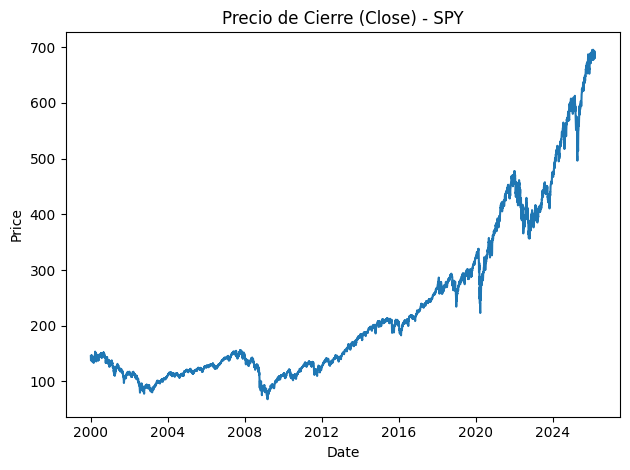

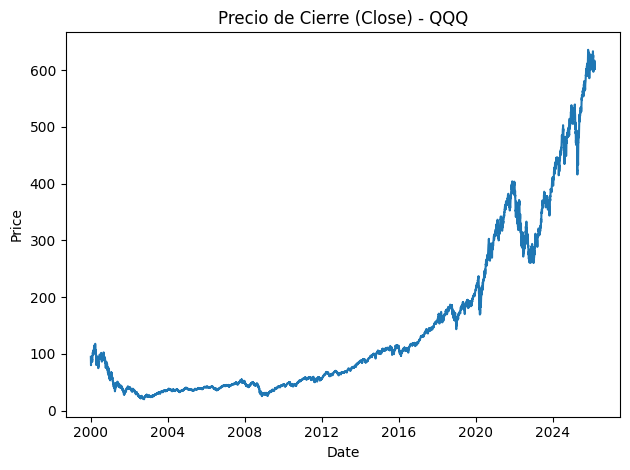

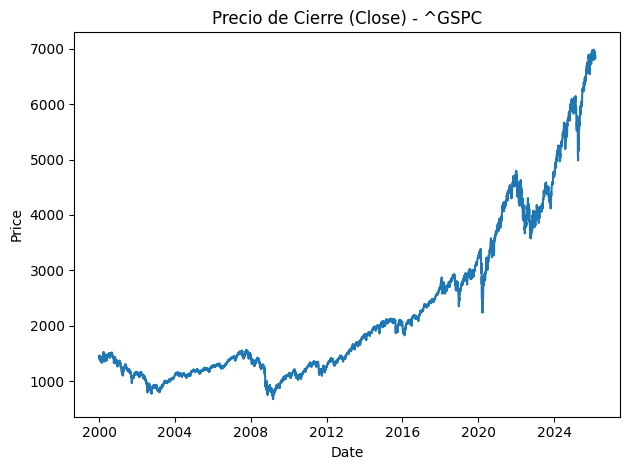

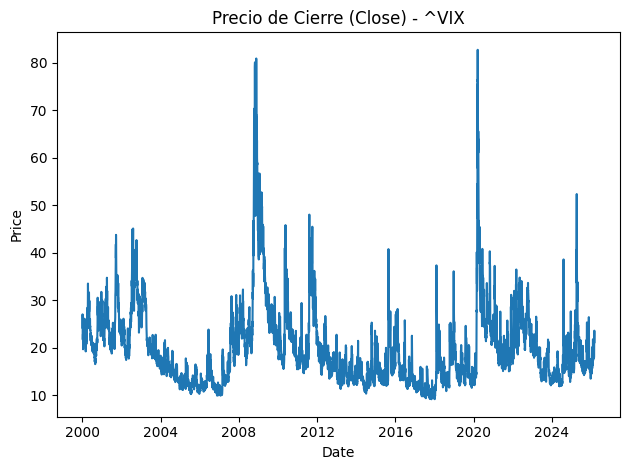

In [25]:
def plot_close_prices(raw_df: pd.DataFrame, tickers: list[str], title: str = "Close Price"):

    if isinstance(raw_df.columns, pd.MultiIndex):
        for t in tickers:
            if (t, "Close") in raw_df.columns:
                plt.figure()
                plt.plot(raw_df.index, raw_df[(t, "Close")])
                plt.title(f"{title} - {t}")
                plt.xlabel("Date")
                plt.ylabel("Price")
                plt.tight_layout()
                plt.show()
    else:
        plt.figure()
        plt.plot(raw_df.index, raw_df["Close"])
        plt.title(f"{title} - {tickers[0]}")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.tight_layout()
        plt.show()

plot_close_prices(raw, TICKERS, "Precio de Cierre (Close)")

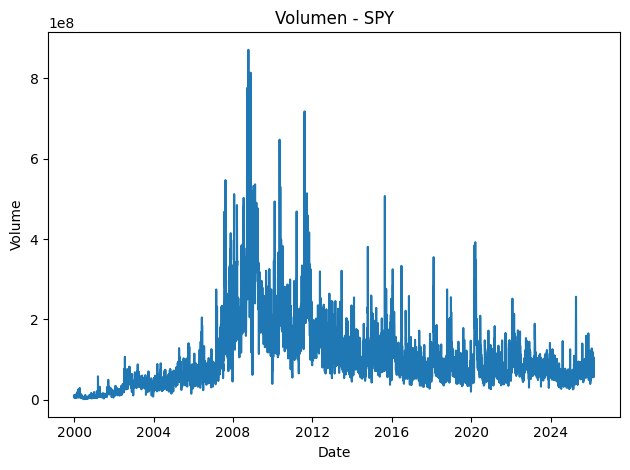

In [14]:
def plot_volume(raw_df: pd.DataFrame, ticker: str):
    plt.figure()
    if isinstance(raw_df.columns, pd.MultiIndex):
        vol = raw_df[(ticker, "Volume")]
        plt.plot(raw_df.index, vol)
        plt.title(f"Volumen - {ticker}")
    else:
        plt.plot(raw_df.index, raw_df["Volume"])
        plt.title(f"Volumen - {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.tight_layout()
    plt.show()

plot_volume(raw, "SPY")

## 7) Rendimientos y volatilidad (base para HMM / Change Point / LSTM)

In [15]:
def get_close_wide(raw_df: pd.DataFrame, tickers: list[str]) -> pd.DataFrame:
    if isinstance(raw_df.columns, pd.MultiIndex):
        close = pd.DataFrame({t: raw_df[(t, "Close")] for t in tickers if (t, "Close") in raw_df.columns})
    else:
        close = raw_df[["Close"]].rename(columns={"Close": tickers[0]})
    return close

close = get_close_wide(raw, TICKERS)
close.tail()

,SPY,QQQ,^GSPC,^VIX
Date,,,,
2026-02-26,689.299988,609.239990,6908.859863,18.629999
2026-02-27,685.989990,607.289978,6878.879883,19.860001
2026-03-02,686.380005,608.090027,6881.620117,21.440001
2026-03-03,680.330017,601.580017,6816.629883,23.570000
2026-03-04,685.130005,610.750000,6869.500000,21.150000


In [16]:
# Rendimientos
ret = close.pct_change()
logret = np.log(close).diff()

# Volatilidad rolling (anualizada aproximada para daily)
ROLL = 21  # ~1 mes bursátil
vol = logret.rolling(ROLL).std() * np.sqrt(252)

ret.describe().T


,count,mean,std,min,25%,50%,75%,max
SPY,6580.0,0.000310,0.012214,-0.109424,-0.004789,0.000629,0.005963,0.145198
QQQ,6580.0,0.000426,0.016904,-0.119788,-0.006516,0.001077,0.007950,0.168421
^GSPC,6580.0,0.000310,0.012174,-0.119841,-0.004725,0.000635,0.005884,0.115800
^VIX,6580.0,0.002618,0.075326,-0.357539,-0.039083,-0.005354,0.034123,1.155979


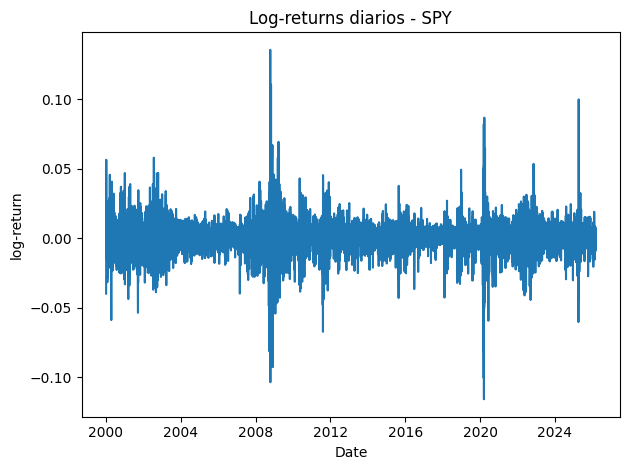

In [17]:
# Gráfica de log-returns (una serie)
ticker_focus = "SPY"
plt.figure()
plt.plot(logret.index, logret[ticker_focus])
plt.title(f"Log-returns diarios - {ticker_focus}")
plt.xlabel("Date")
plt.ylabel("log-return")
plt.tight_layout()
plt.show()


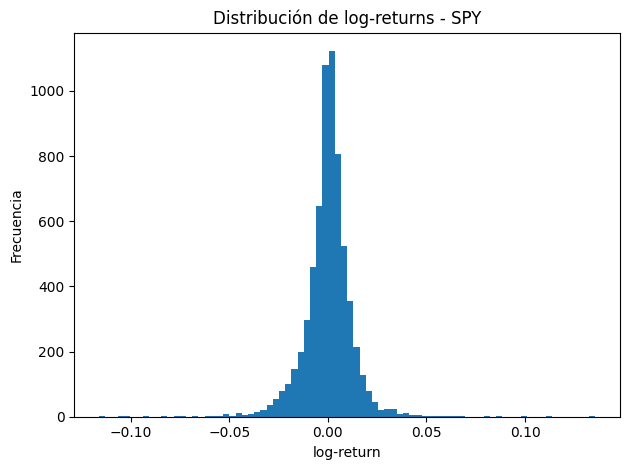

,0
mean,0.000236
std,0.012219
skew,-0.206338
kurtosis,11.471691


In [18]:
# Histograma de returns + momentos
plt.figure()
vals = logret[ticker_focus].dropna().values
plt.hist(vals, bins=80)
plt.title(f"Distribución de log-returns - {ticker_focus}")
plt.xlabel("log-return")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

moments = pd.Series({
    "mean": np.mean(vals),
    "std": np.std(vals),
    "skew": pd.Series(vals).skew(),
    "kurtosis": pd.Series(vals).kurtosis()
})
moments


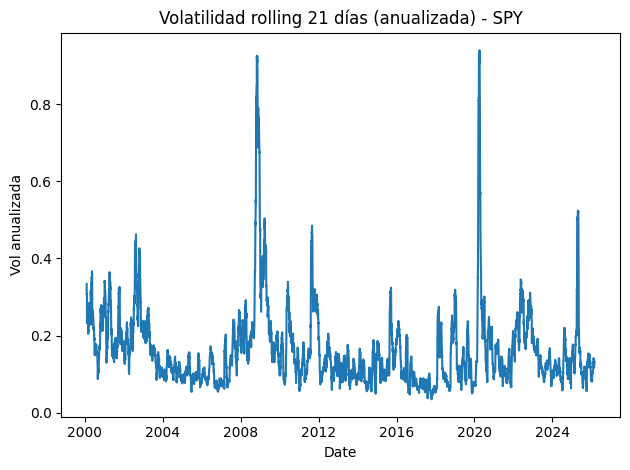

In [19]:
# Volatilidad rolling
plt.figure()
plt.plot(vol.index, vol[ticker_focus])
plt.title(f"Volatilidad rolling {ROLL} días (anualizada) - {ticker_focus}")
plt.xlabel("Date")
plt.ylabel("Vol anualizada")
plt.tight_layout()
plt.show()


## 8) Drawdown (crisis 2008, COVID, etc.)

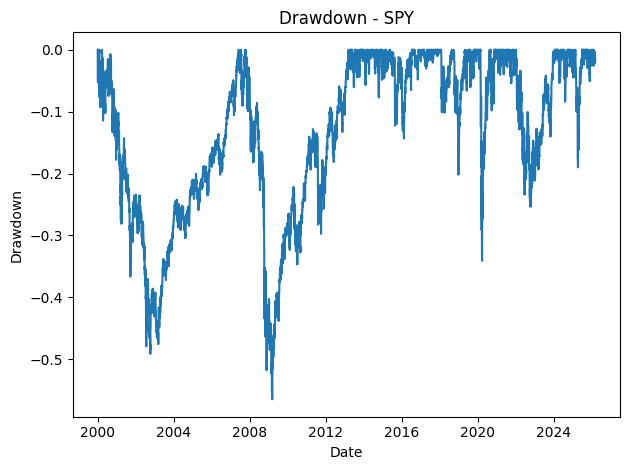

,drawdown
count,6581.000000
mean,-0.130029
std,0.128631
min,-0.564737
25%,-0.217582
50%,-0.088314
75%,-0.015550
max,0.000000


In [20]:
def compute_drawdown(price: pd.Series) -> pd.DataFrame:
    cummax = price.cummax()
    dd = price / cummax - 1.0
    return pd.DataFrame({"price": price, "cummax": cummax, "drawdown": dd})

dd = compute_drawdown(close[ticker_focus].dropna())

plt.figure()
plt.plot(dd.index, dd["drawdown"])
plt.title(f"Drawdown - {ticker_focus}")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()

dd["drawdown"].describe()


## 9) Comparación multi-activo: correlaciones

In [21]:
corr = logret.dropna().corr()
corr


,SPY,QQQ,^GSPC,^VIX
SPY,1.000000,0.855004,0.986541,-0.728415
QQQ,0.855004,1.000000,0.848000,-0.624137
^GSPC,0.986541,0.848000,1.000000,-0.732070
^VIX,-0.728415,-0.624137,-0.732070,1.000000


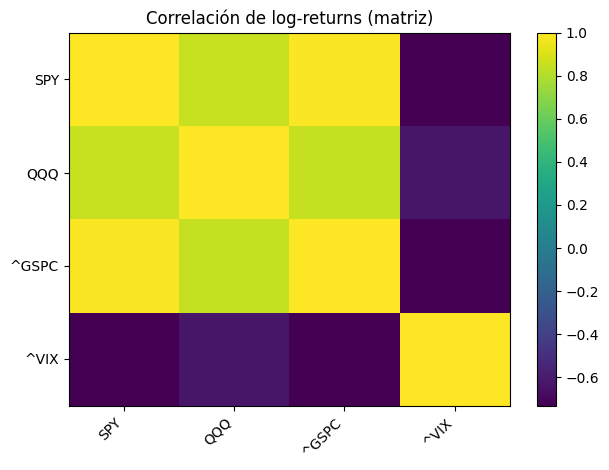

In [22]:
# Heatmap simple con matplotlib (sin seaborn)
plt.figure()
plt.imshow(corr.values, aspect="auto")
plt.title("Correlación de log-returns (matriz)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()


## 10) Señales simples de tendencia (MA crossover)

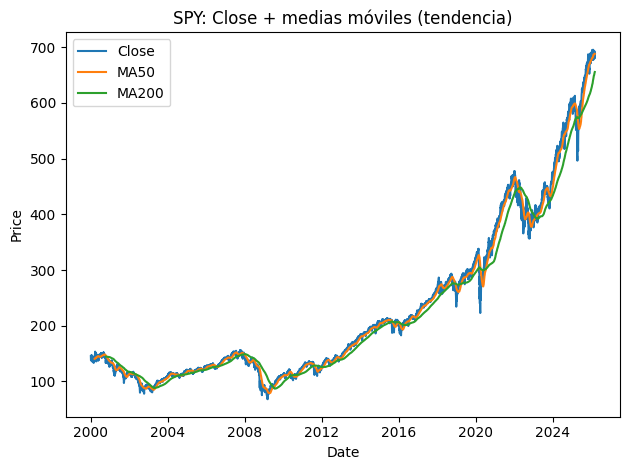

,count
SPY,
1,4510
0,2071


In [23]:
SHORT = 50
LONG = 200

ma_s = close[ticker_focus].rolling(SHORT).mean()
ma_l = close[ticker_focus].rolling(LONG).mean()
signal = (ma_s > ma_l).astype(int)

plt.figure()
plt.plot(close.index, close[ticker_focus], label="Close")
plt.plot(ma_s.index, ma_s, label=f"MA{SHORT}")
plt.plot(ma_l.index, ma_l, label=f"MA{LONG}")
plt.title(f"{ticker_focus}: Close + medias móviles (tendencia)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

signal.value_counts()


## 11) Tabla resumen final (por ticker)

In [24]:
summary_rows = []
for t in close.columns:
    s = close[t].dropna()
    if len(s) < 300:
        continue
    lr = np.log(s).diff().dropna()
    ann_ret = lr.mean() * 252
    ann_vol = lr.std() * np.sqrt(252)
    max_dd = compute_drawdown(s)["drawdown"].min()
    summary_rows.append({
        "Ticker": t,
        "start": s.index.min().date(),
        "end": s.index.max().date(),
        "n_obs": len(s),
        "ann_log_return": float(ann_ret),
        "ann_vol": float(ann_vol),
        "max_drawdown": float(max_dd),
    })

summary = pd.DataFrame(summary_rows).set_index("Ticker").sort_index()
summary


,start,end,n_obs,ann_log_return,ann_vol,max_drawdown
Ticker,,,,,,
QQQ,2000-01-03,2026-03-04,6581,0.071366,0.268034,-0.829639
SPY,2000-01-03,2026-03-04,6581,0.059356,0.193978,-0.564737
^GSPC,2000-01-03,2026-03-04,6581,0.059436,0.193515,-0.567754
^VIX,2000-01-03,2026-03-04,6581,-0.005175,1.137118,-0.886965
